Brief analysis , igraph

In [2]:
# import graph

import os
import pickle
import igraph as ig
import matplotlib.pyplot as plt

# 1. Definiamo il percorso del file del 1986
test_year = 1986
file_path = f"data/processed/actor_projections/actors_projected_{test_year}.pkl"

with open(file_path, 'rb') as f:
        g = pickle.load(f)

In [5]:
g.summary(verbosity=1)

'IGRAPH UNW- 866 3615 -- \n+ attr: year (g), age (v), gender (v), genre (v), name (v), weight (e)\n+ edges (vertex names):\n             Nicholas Pryor -- Stephen Collins, Janet Julian, Bo Svenson, Lance Henriksen, Victoria Racimo, Robert Hoy, Walter Robles, Michael Flynn\n            Stephen Collins -- Nicholas Pryor, Janet Julian, Bo Svenson, Lance Henriksen, Victoria Racimo, Robert Hoy, Walter Robles, Michael Flynn\n               Janet Julian -- Nicholas Pryor, Stephen Collins, Bo Svenson, Lance Henriksen, Victoria Racimo, Robert Hoy, Walter Robles, Michael Flynn\n                 Bo Svenson -- Nicholas Pryor, Stephen Collins, Janet Julian, Lance Henriksen, Victoria Racimo, Robert Hoy, Walter Robles, Michael Flynn, Martin Balsam, Chuck Norris, Lee Marvin, Joey Bishop, Robert Forster, Lainie Kazan, George Kennedy, Hanna Schygulla, Susan Strasberg, Robert Vaughn, Shelley Winters, Kim Delaney, Kevin Dillon, Liam Neeson\n            Lance Henriksen -- Nicholas Pryor, Stephen Collins, J

In [7]:
n = g.vcount()
e = g.ecount()

print(f"graph has {n} nodes and {e} edges")

graph has 866 nodes and 3615 edges


In [ ]:
# # cicle on vertex and edges

# for v in g.vs:
#     print(v)

# for e in g.es:
#     print(e)

In [11]:
# diameter
d = g.diameter()
print(f" diameter: {d}")

 diameter: 24


In [12]:
g.average_path_length()

7.832640901986454

In [13]:
g.degree_distribution()

In [17]:
import igraph as ig
import matplotlib.pyplot as plt
communities = g.community_edge_betweenness()
communities = communities.as_clustering()

In [18]:
num_communities = len(communities)
palette = ig.RainbowPalette(n=num_communities)
for i, community in enumerate(communities):
    g.vs[community]["color"] = i
    community_edges = g.es.select(_within=community)
    community_edges["color"] = i

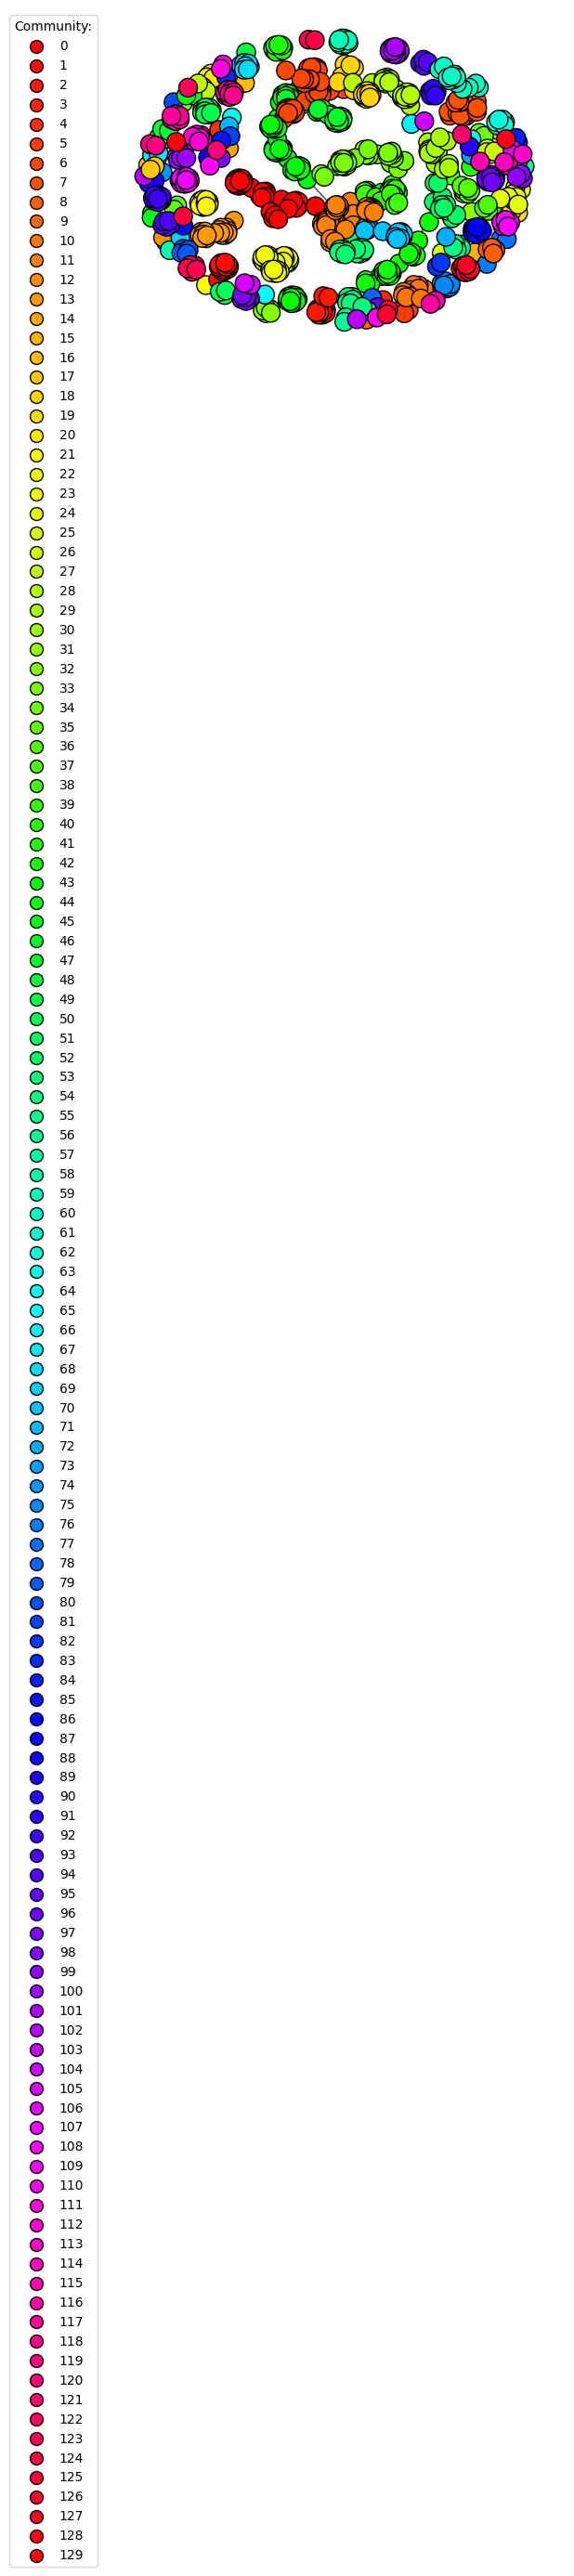

In [19]:
fig, ax = plt.subplots()
ig.plot(
    communities,
    palette=palette,
    edge_width=1,
    target=ax,
    vertex_size=20,
)

# Create a custom color legend
legend_handles = []
for i in range(num_communities):
    handle = ax.scatter(
        [],
        [],
        s=100,
        facecolor=palette.get(i),
        edgecolor="k",
        label=i,
    )
    legend_handles.append(handle)
ax.legend(
    handles=legend_handles,
    title="Community:",
    bbox_to_anchor=(0, 1.0),
    bbox_transform=ax.transAxes,
)
plt.show()

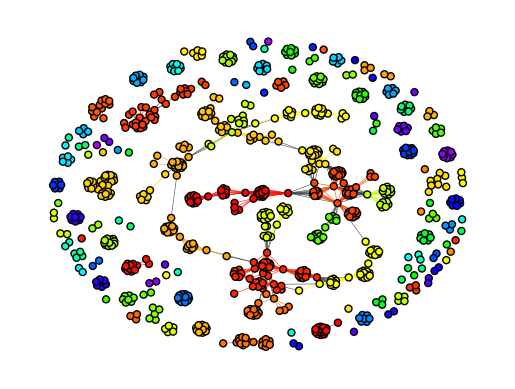

In [22]:
# visualizing connected components
import igraph as ig
import matplotlib.pyplot as plt
import random

random.seed(0)
components = g.connected_components(mode="weak")

fig, ax = plt.subplots()
ig.plot(
    components,
    target=ax,
    palette=ig.RainbowPalette(),
    vertex_size=7,
    vertex_color=list(map(int, ig.rescale(components.membership, (0, 200), clamp=True))),
    edge_width=0.4
)
plt.show()

In [ ]:
# Generating Cluster Graphs

